# Cloning the Repo

In [1]:
#!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection

[WinError 2] Impossibile trovare il file specificato: 'Continual-hate-speech-detection'
c:\Uni\Continual-hate-speech-detection


# Install all the necessary library

In [2]:
%pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## ⚙️ Imports & configuration

Loads all project modules and sets global constants. `DEVICE` auto-selects GPU if available.

`BATCH_SIZE=32` and `EVAL_EVERY=75` were chosen after empirical testing, smaller batches
increase ADWIN noise, larger eval intervals reduce training overhead without losing curve granularity.

In [3]:
import os
import torch
from transformers import AutoTokenizer

from dataset.df_loader   import LABEL_MAP, load_davidson, load_hatexplain, get_class_weights
from dataset.stream_generator import create_stream, create_continual_stream, stream_info
from model_utils.model_builder         import HateSpeechClassifier
from model_utils.trainer             import ContinualTrainer
from model_utils.tuner import ContinualTuner
from strategy.replay     import ReplayStrategy
from strategy.ewc        import EWCStrategy
from strategy.derpp       import DERppStrategy
from utils.metrics       import compute_accuracy, compute_f1, compute_all
from utils.plot_utils    import (
    plot_label_distribution, plot_stream_shift,
    plot_loss, plot_eval_log, plot_conf_matrix,
    plot_comparison, plot_eval_logs_comparison,
    plot_per_class_f1, plot_posttrain_davidson
)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EVAL_EVERY = 75
print(f"Device: {DEVICE} | GPU: {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

Device: cuda | GPU: NVIDIA GeForce RTX 5070 Laptop GPU


## 📂 Dataset loading

Loads Davidson (HuggingFace) and HateXplain (GitHub JSON) and builds the continual stream.
The two datasets are concatenated in order with no inter-dataset shuffle, this is intentional.
The abrupt shift at the boundary is what makes this a meaningful CL scenario.

Davidson: ~19,000 tweets, 78% offensive.
HateXplain: ~15,000 posts, roughly balanced across the three classes.

In [4]:
train_dv, val_dv = load_davidson()
train_hx, val_hx = load_hatexplain()

class_weights = get_class_weights(train_dv, train_hx)

stream        = create_continual_stream(train_dv, train_hx, batch_size=BATCH_SIZE)
val_stream_dv = create_stream(val_dv, batch_size=BATCH_SIZE)
val_stream_hx = create_stream(val_hx, batch_size=BATCH_SIZE)
VAL_STREAMS   = {"davidson": val_stream_dv, "hatexplain": val_stream_hx}
BOUNDARY      = len(create_stream(train_dv, batch_size=BATCH_SIZE))

stream_info(stream, "full stream")

Davidson   — train: 19448 | val: 4862
HateXplain — train: 16115 | val: 4029
  hatespeech  : 1.868
  offensive   : 0.609
  normal      : 1.216
full stream: 1112 batches | 35563 samples | {'davidson': 19448, 'hatexplain': 16115}


## 📊 Dataset analysis

Visual inspection of the two datasets before training. The label distribution plot shows
the prior shift clearly, Davidson is dominated by "offensive" while HateXplain is balanced.
The stream shift plot shows how class ratios change abruptly at the dataset boundary.
This shift is what the anti-forgetting strategies are designed to handle.

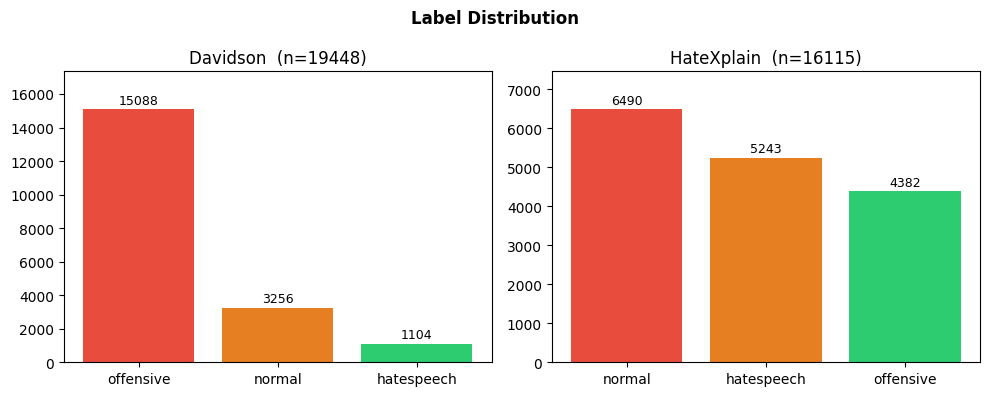

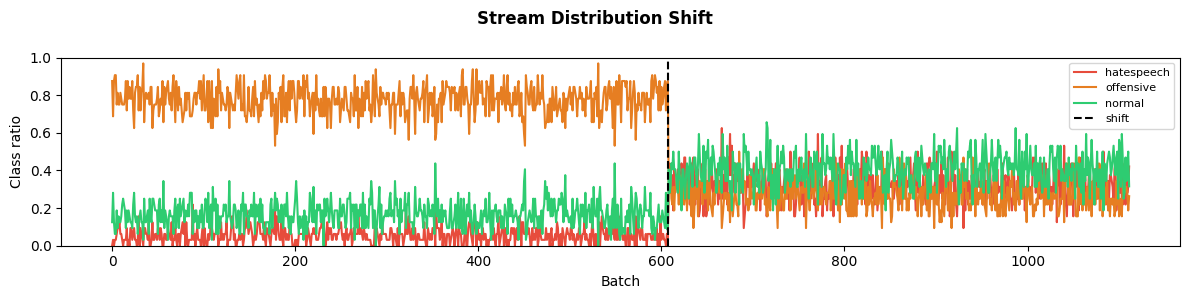

In [5]:
plot_label_distribution(train_dv, train_hx, names=["Davidson", "HateXplain"])
plot_stream_shift(stream)

## 🧪 Experiment setup

Defines the five strategies with clean state at each run to prevent any weight or
buffer contamination between experiments.

The `ContinualTrainer` processes the stream one batch at a time without any shuffling
between datasets. At each step it computes the forward pass, accumulates the strategy
losses (replay CE, EWC penalty, DER++ distillation), backpropagates the total loss,
and feeds the batch error rate to ADWIN. When ADWIN triggers, the trainer pre-splits
the recent buffer into old and new task batches, calls `on_task_end` on each strategy
(EWC computes Fisher, Replay and DER++ activate), then runs the HP tuner on the same
split before resuming training.

The model is a DistilRoBERTa backbone with the bottom three layers frozen and the top
three trainable, followed by a two-layer classification head initialized with Xavier
uniform. Label smoothing ε=0.1 is applied to the CE loss to reduce overconfidence on
the dominant class. A differential learning rate is used:
- `lr=2e-5` for the backbone
- `lr_head=1e-4` for the head, 


the head trains from scratch so it needs a higher rate to converge at the same pace as the pretrained backbone.

In [ ]:
os.makedirs("models", exist_ok=True)
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilroberta-base")

EXPERIMENTS = {
    "Baseline":   lambda: [],
    "Replay":     lambda: [ReplayStrategy(buffer_size=1000)],
    "EWC":        lambda: [EWCStrategy()],
    "Replay+EWC": lambda: [ReplayStrategy(buffer_size=1000), EWCStrategy()],
    "DER++":      lambda: [DERppStrategy()],
}

cl_results = {}

def _run_experiment(name, strategy_factory):
    print(f"\n{'='*50}\nExperiment: {name}\n{'='*50}")

    model     = HateSpeechClassifier(num_labels=3)
    trainer   = ContinualTrainer(model, tokenizer, device=DEVICE, lr=2e-5, adwin_delta=0.001, lr_decay=0.5)
    strategies = strategy_factory()

    for s in strategies:
        trainer.add_strategy(s)

    if strategies:
        trainer.set_tuner(ContinualTuner(strategies))

    result = trainer.train(stream, LABEL_MAP, VAL_STREAMS, eval_every=EVAL_EVERY)
    losses = result["task"]

    preds_dv, labels_dv = trainer.evaluate(val_stream_dv, LABEL_MAP)
    preds_hx, labels_hx = trainer.evaluate(val_stream_hx, LABEL_MAP)
    metrics = compute_all(trainer.eval_log, "davidson", "hatexplain",
                          boundary_batch=BOUNDARY)

    print(f"Davidson   — Acc={compute_accuracy(preds_dv,labels_dv):.4f} | F1={compute_f1(preds_dv,labels_dv):.4f}")
    print(f"HateXplain — Acc={compute_accuracy(preds_hx,labels_hx):.4f} | F1={compute_f1(preds_hx,labels_hx):.4f}")
    print(f"Drift at batch: {trainer.drift_batch}")

    cl_results[name] = {
        "losses":   losses,          
        "eval_log": trainer.eval_log,
        "metrics":  metrics,
        "drift_at": trainer.drift_batch,
        "preds_dv": preds_dv, "labels_dv": labels_dv,
        "preds_hx": preds_hx, "labels_hx": labels_hx,
    }

    safe_name = name.replace("+", "_").replace(" ", "_")
    trainer.save(f"models/{safe_name}.pt")
    print(f"Model saved → models/{safe_name}.pt")
    

## 📉 Baseline

No anti-forgetting strategy. The model trains normally on the full stream without any
mechanism to protect knowledge from Davidson. This is the worst-case reference point
all improvements from the other strategies are measured relative to this.


Experiment: Baseline


Training:  61%|██████    | 673/1112 [02:46<00:13, 31.66it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x


Training: 100%|██████████| 1112/1112 [04:39<00:00,  3.98it/s]


BWT  (davidson): -0.1380  (forgetting)
FWT  (hatexplain):  0.4105  (zero-shot before training)
AAA  (all tasks):  0.6360  (avg anytime accuracy)
Davidson   — Acc=0.7690 | F1=0.5917
HateXplain — Acc=0.6647 | F1=0.6367
Drift at batch: 671
Model saved → models/Baseline.pt


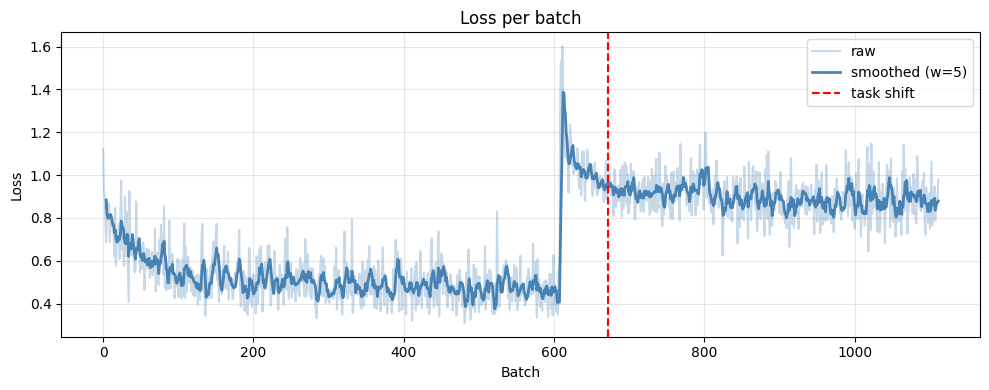

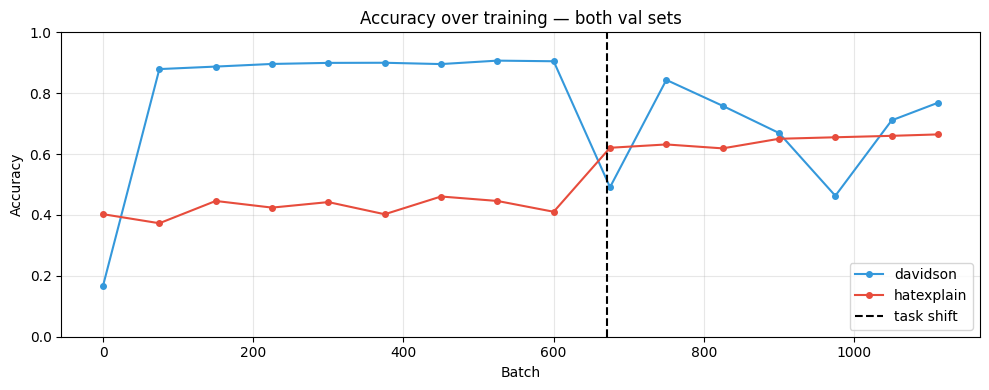

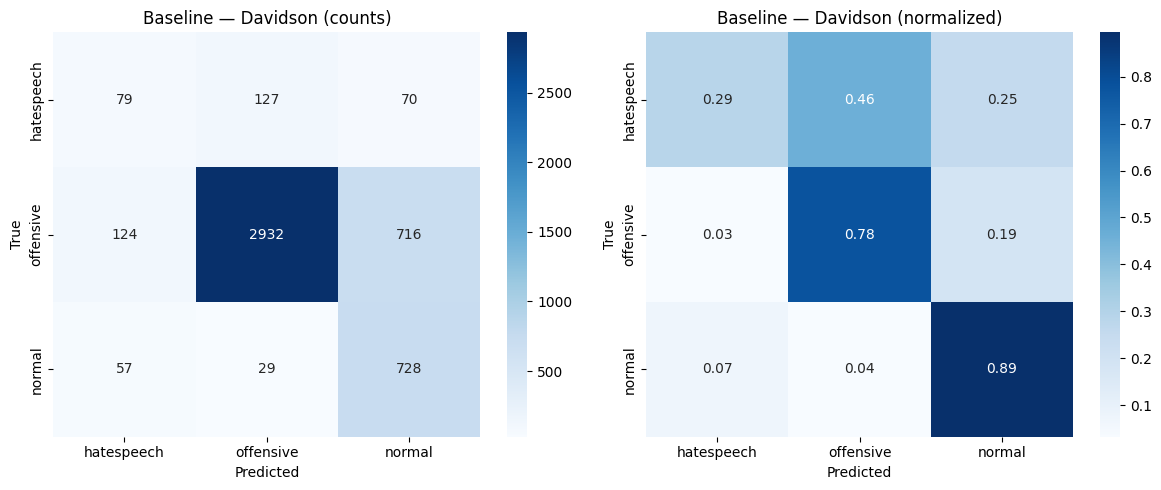

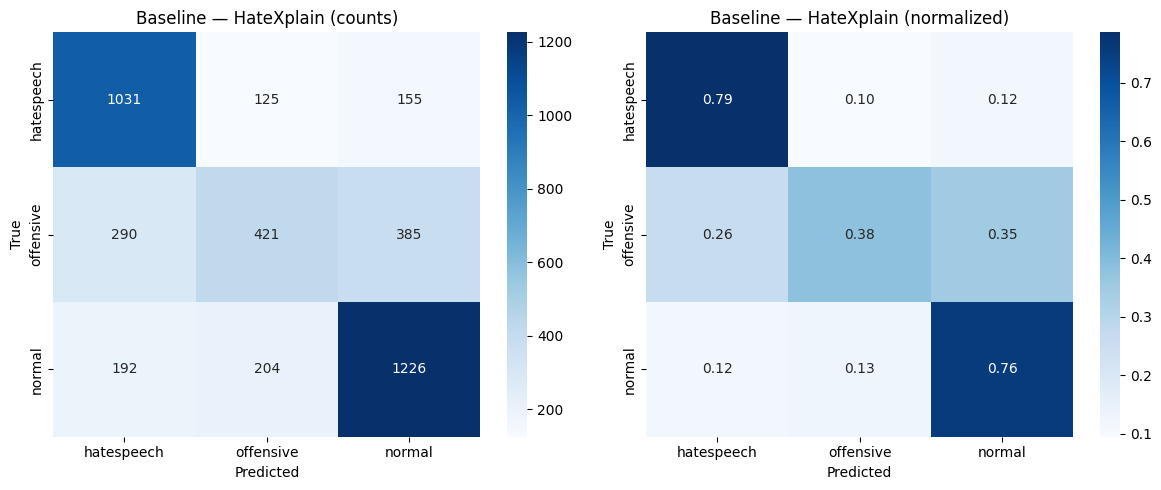

In [7]:
_run_experiment("Baseline", EXPERIMENTS["Baseline"])

res = cl_results["Baseline"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Baseline — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Baseline — HateXplain")

## 🔁 Replay

Class-balanced reservoir sampling maintains one buffer per class with capacity:

$$\text{slot\_size} = \left\lfloor \frac{\text{buffer\_size}}{\text{n\_classes}} \right\rfloor$$

Each new sample replaces a random existing one with probability $\text{slot\_size}/t$
where $t$ is the total samples seen for that class, guaranteeing uniform representation
across the full first task regardless of stream order.

The buffer fills silently during Davidson and activates only at drift detection.
Post-drift, each training step samples a mini-batch from the buffer and adds a CE
replay loss alongside the current task loss, forcing the model to keep predicting
Davidson samples correctly while adapting to HateXplain.


Experiment: Replay


Training:  60%|██████    | 669/1112 [02:58<00:14, 29.56it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x

[Tuner] HP search on 137 old + 63 new batches


Training:  61%|██████    | 673/1112 [03:06<04:25,  1.66it/s]

[Tuner] Plasticity ceiling A = 0.7133


Training: 100%|██████████| 1112/1112 [05:17<00:00,  3.51it/s]


BWT  (davidson): -0.0385  (forgetting)
FWT  (hatexplain):  0.4368  (zero-shot before training)
AAA  (all tasks):  0.6865  (avg anytime accuracy)
Davidson   — Acc=0.8696 | F1=0.7047
HateXplain — Acc=0.6438 | F1=0.6097
Drift at batch: 671
Model saved → models/Replay.pt


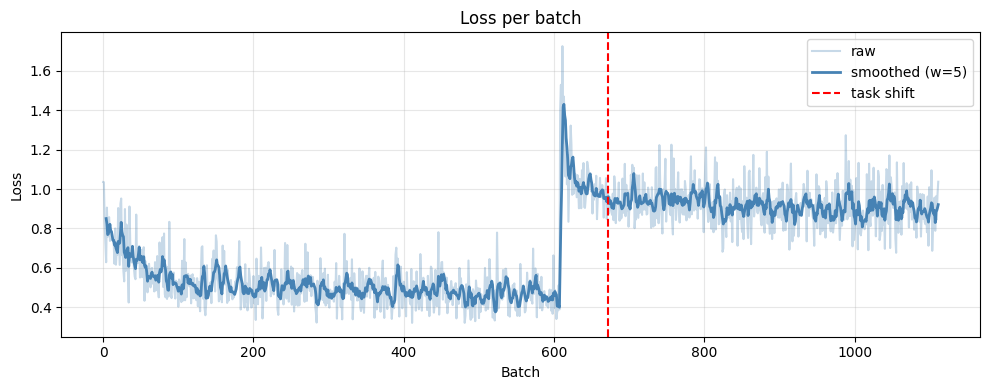

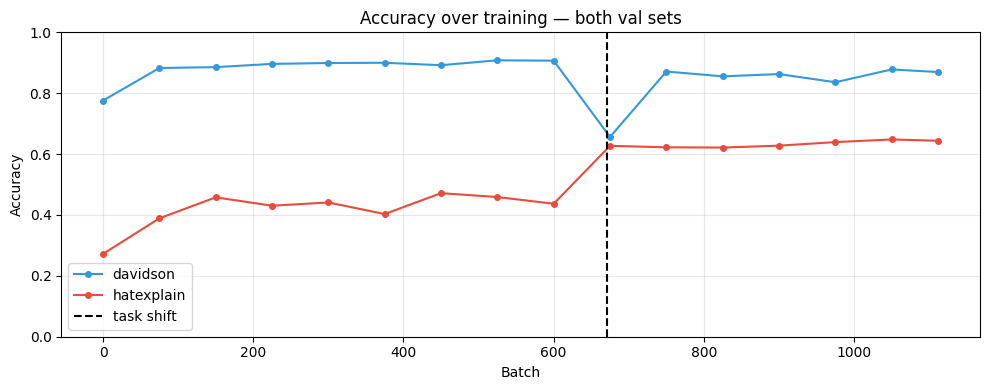

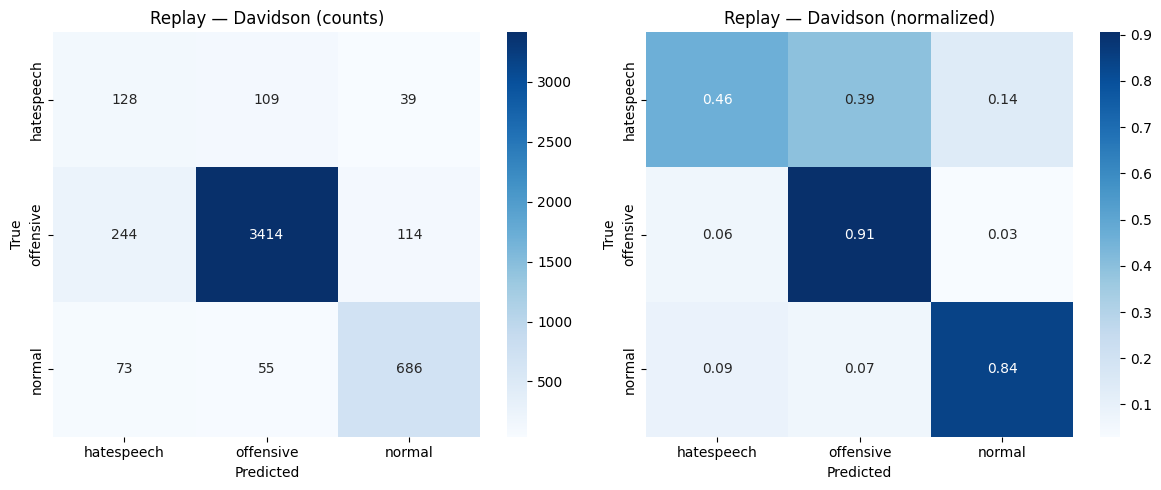

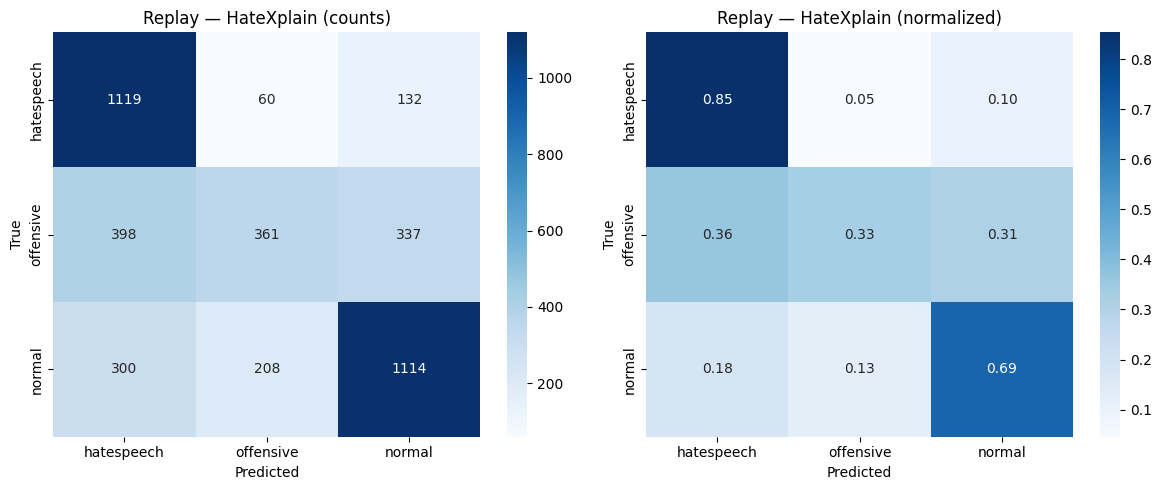

In [8]:
_run_experiment("Replay", EXPERIMENTS["Replay"])

res = cl_results["Replay"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Replay — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Replay — HateXplain")

## 🔒 EWC

Elastic Weight Consolidation computes the Fisher information matrix on old task data
at drift detection and penalizes any deviation from the reference parameters:

$$L_{EWC} = L_{CE} + \lambda \sum_i F_i \left(\theta_i - \theta^*_i\right)^2$$

The Practical Fisher variant is used — labels are sampled from the model's own output
distribution rather than ground truth to avoid gradient bias. Fisher is computed
exclusively on `old_batches` (the pre-drift portion of the recent buffer) to avoid
contamination from HateXplain samples that entered the buffer before ADWIN triggered.

Run in isolation as an ablation to isolate EWC's contribution independently from Replay.


Experiment: EWC


Training:  60%|██████    | 671/1112 [03:00<00:19, 23.06it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x


Training:  60%|██████    | 671/1112 [03:17<00:19, 23.06it/s]

[EWC] Fisher computed on 137 batches (lambda=0.1)

[Tuner] HP search on 137 old + 63 new batches
[Tuner] Plasticity ceiling A = 0.7123
[Tuner] Searching EWCStrategy over 3 configs...
  {'lambda_': 0.01} → A*=0.6905 forgetting=0.0914 ✓
  {'lambda_': 0.1} → A*=0.6959 forgetting=0.1012 ✓


Training:  61%|██████    | 675/1112 [05:05<1:07:35,  9.28s/it]

  {'lambda_': 1.0} → A*=0.6939 forgetting=0.0985 ✓
[Tuner] Best: {'lambda_': 0.01} (forgetting=0.0914)


Training: 100%|██████████| 1112/1112 [06:55<00:00,  2.68it/s] 


BWT  (davidson): -0.1654  (forgetting)
FWT  (hatexplain):  0.4351  (zero-shot before training)
AAA  (all tasks):  0.6352  (avg anytime accuracy)
Davidson   — Acc=0.7402 | F1=0.5829
HateXplain — Acc=0.6674 | F1=0.6341
Drift at batch: 671
Model saved → models/EWC.pt


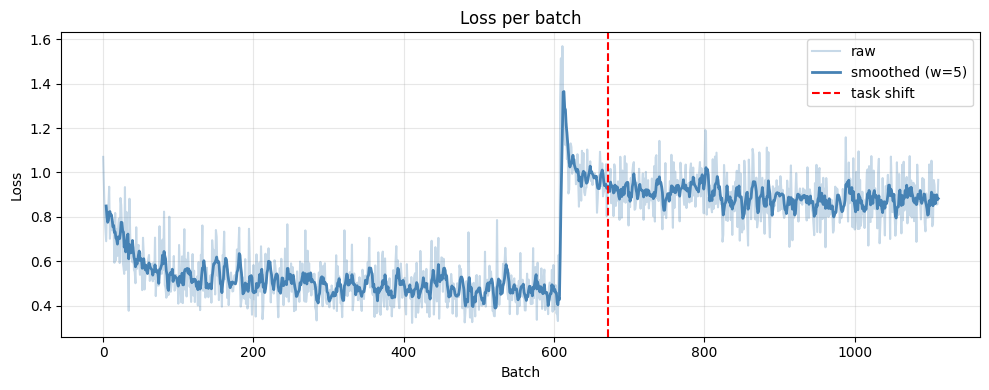

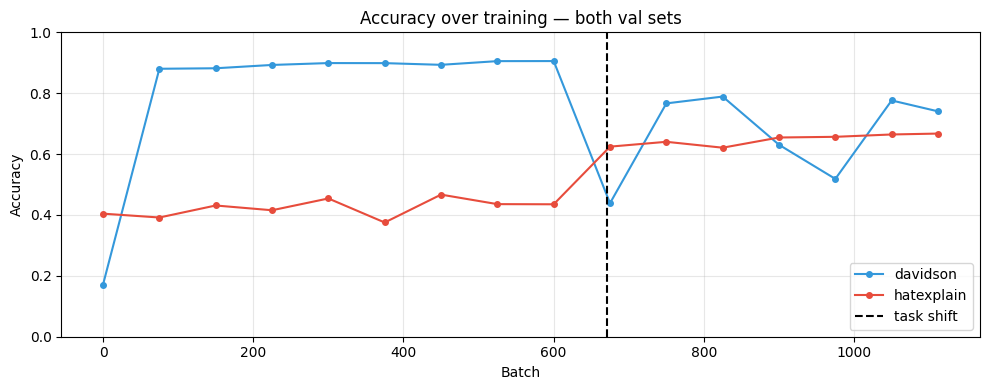

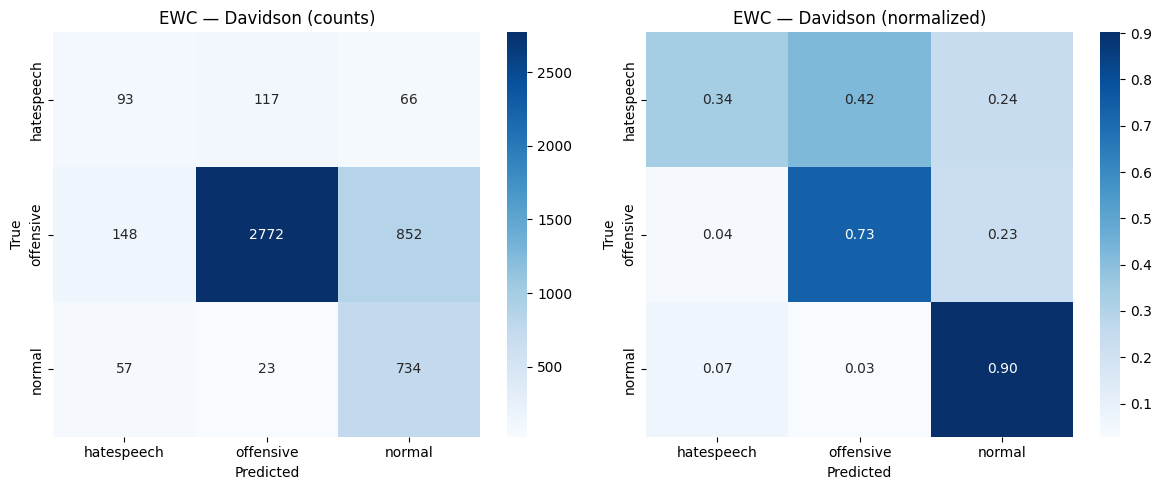

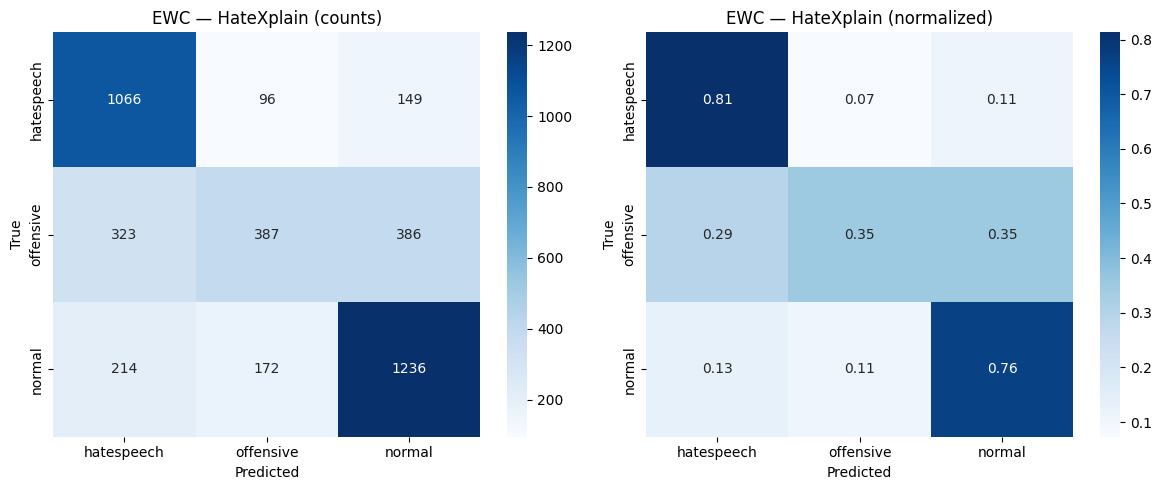

In [9]:
_run_experiment("EWC", EXPERIMENTS["EWC"])

res = cl_results["EWC"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="EWC — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="EWC — HateXplain")

## 🔁🔒 Replay + EWC

Combines Replay and EWC acting on different dimensions: Replay brings Davidson samples
back into the gradient computation, while EWC penalizes movement away from the Davidson
parameter optimum.

The lambda controlling the EWC penalty is tuned automatically at drift by the continual
tuner, which searches over three candidate values and selects the one that minimizes
forgetting while keeping plasticity on HateXplain within 5% of the unconstrained ceiling.


Experiment: Replay+EWC


Training:  60%|██████    | 668/1112 [02:07<00:12, 34.18it/s]


[ADWIN] Drift detected at batch 671
[ADWIN] LR decayed by 0.5x
[EWC] Fisher computed on 137 batches (lambda=0.1)

[Tuner] HP search on 137 old + 63 new batches
[Tuner] Plasticity ceiling A = 0.7158
[Tuner] Searching EWCStrategy over 3 configs...


Training:  60%|██████    | 668/1112 [02:25<00:12, 34.18it/s]

  {'lambda_': 0.01} → A*=0.6935 forgetting=0.0957 ✓
  {'lambda_': 0.1} → A*=0.6885 forgetting=0.0752 ✓


Training:  61%|██████    | 674/1112 [03:29<36:41,  5.03s/it]

  {'lambda_': 1.0} → A*=0.6954 forgetting=0.0937 ✓
[Tuner] Best: {'lambda_': 0.1} (forgetting=0.0752)


Training: 100%|██████████| 1112/1112 [05:13<00:00,  3.54it/s]


BWT  (davidson): -0.0298  (forgetting)
FWT  (hatexplain):  0.4214  (zero-shot before training)
AAA  (all tasks):  0.6785  (avg anytime accuracy)
Davidson   — Acc=0.8774 | F1=0.7147
HateXplain — Acc=0.6453 | F1=0.6150
Drift at batch: 671
Model saved → models/Replay_EWC.pt


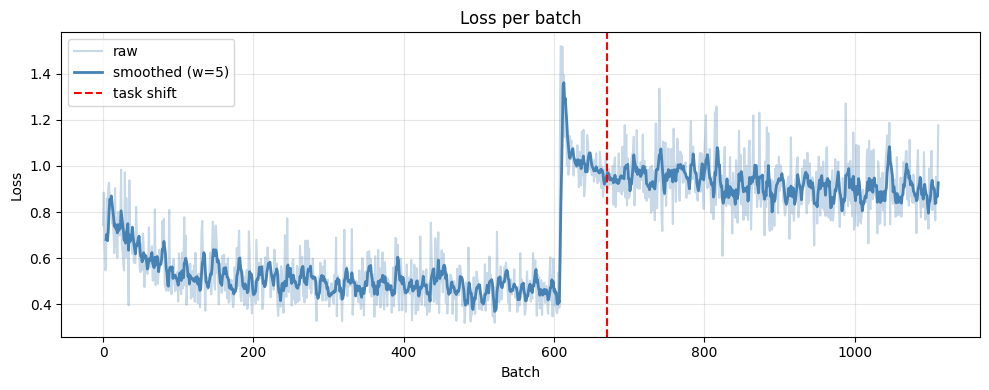

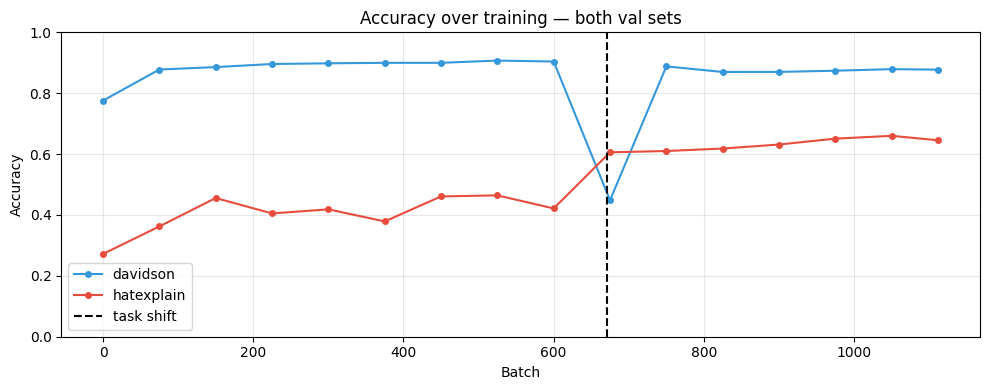

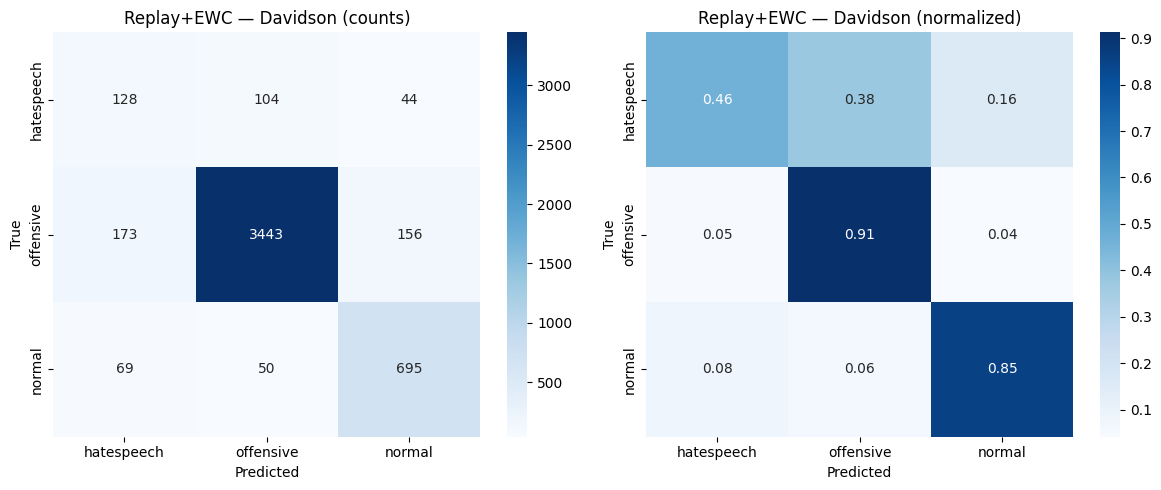

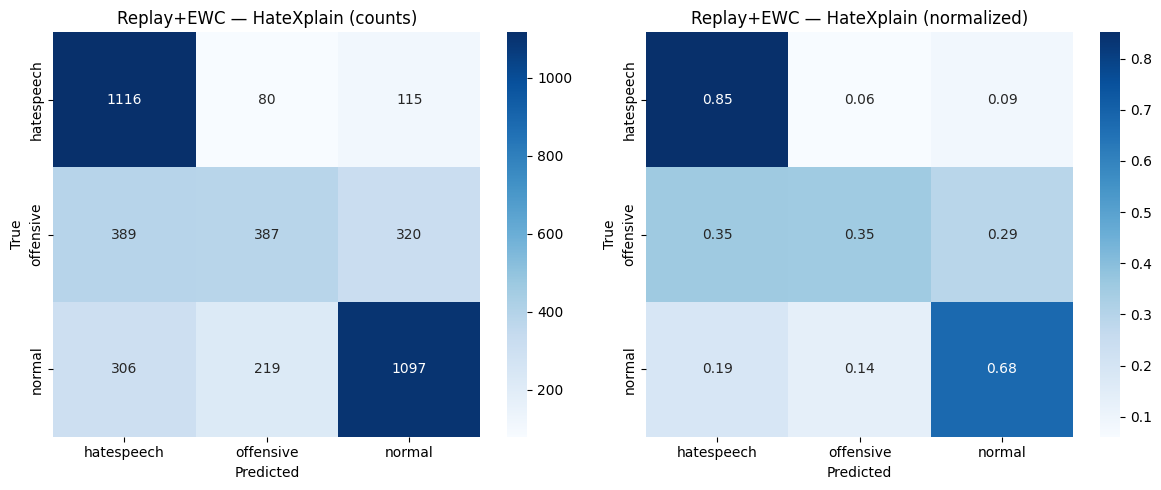

In [10]:
_run_experiment("Replay+EWC", EXPERIMENTS["Replay+EWC"])

res = cl_results["Replay+EWC"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="Replay+EWC — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="Replay+EWC — HateXplain")

## ⚡ DER++

Dark Experience Replay++ stores the model's output logits at the time each sample
enters the buffer alongside its label. At replay time, a distillation loss penalizes
the model for changing what it used to predict on those samples:

$$L_{DER++} = L_{CE}(\text{batch}) + \alpha \cdot \text{MSE}(\hat{z}, z^*) + \beta \cdot L_{CE}(\hat{z}, y^*)$$

The MSE term preserves the full output distribution rather than just the argmax label,
capturing more information than label-only replay. The alpha controlling the distillation
weight is tuned automatically at drift by the continual tuner using the strategy buffer
as the old task proxy for forgetting evaluation.


Experiment: DER++


Training:  57%|█████▋    | 639/1112 [02:07<00:30, 15.58it/s]


[ADWIN] Drift detected at batch 639
[ADWIN] LR decayed by 0.5x

[Tuner] HP search on 169 old + 31 new batches
[Tuner] Plasticity ceiling A = 0.6784
[Tuner] Forgetting eval on strategy buffer (498 samples)
[Tuner] Searching DERppStrategy over 3 configs...


Training:  57%|█████▋    | 639/1112 [02:22<00:30, 15.58it/s]

  {'alpha': 0.1, 'beta': 1.0} → A*=0.6482 forgetting=0.1627 ✓
  {'alpha': 0.3, 'beta': 1.0} → A*=0.6331 forgetting=0.1667 ✗ (plasticity too low)


Training:  58%|█████▊    | 642/1112 [03:11<38:26,  4.91s/it]

  {'alpha': 0.5, 'beta': 1.0} → A*=0.6341 forgetting=0.1586 ✗ (plasticity too low)
[Tuner] Best: {'alpha': 0.1, 'beta': 1.0} (forgetting=0.1627)


Training: 100%|██████████| 1112/1112 [04:46<00:00,  3.88it/s]


BWT  (davidson): -0.0354  (forgetting)
FWT  (hatexplain):  0.4574  (zero-shot before training)
AAA  (all tasks):  0.6705  (avg anytime accuracy)
Davidson   — Acc=0.8700 | F1=0.7159
HateXplain — Acc=0.6518 | F1=0.6213
Drift at batch: 639
Model saved → models/DER__.pt


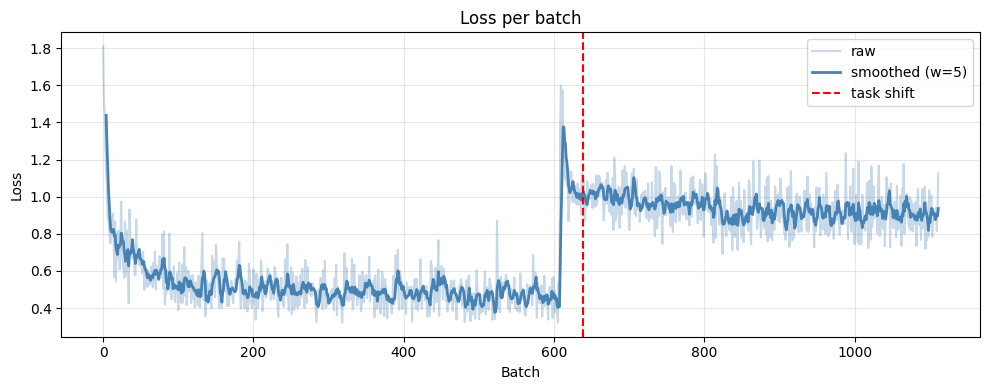

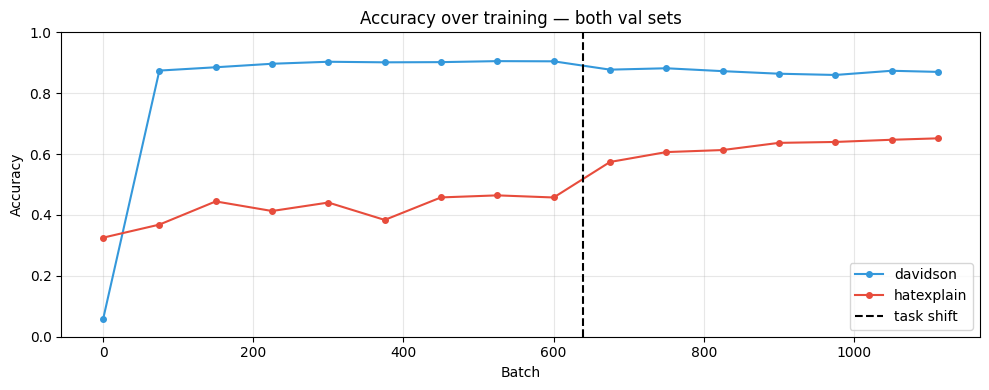

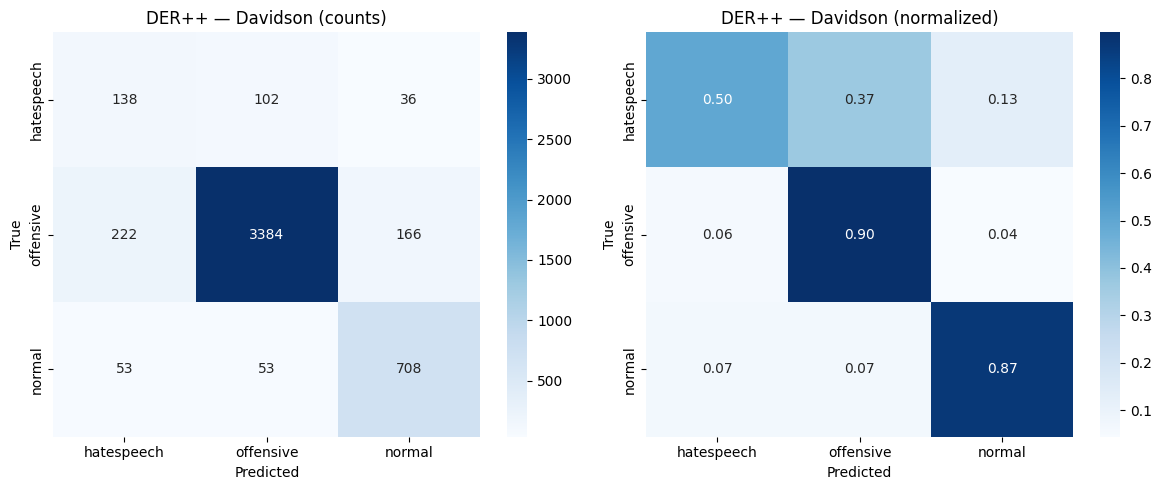

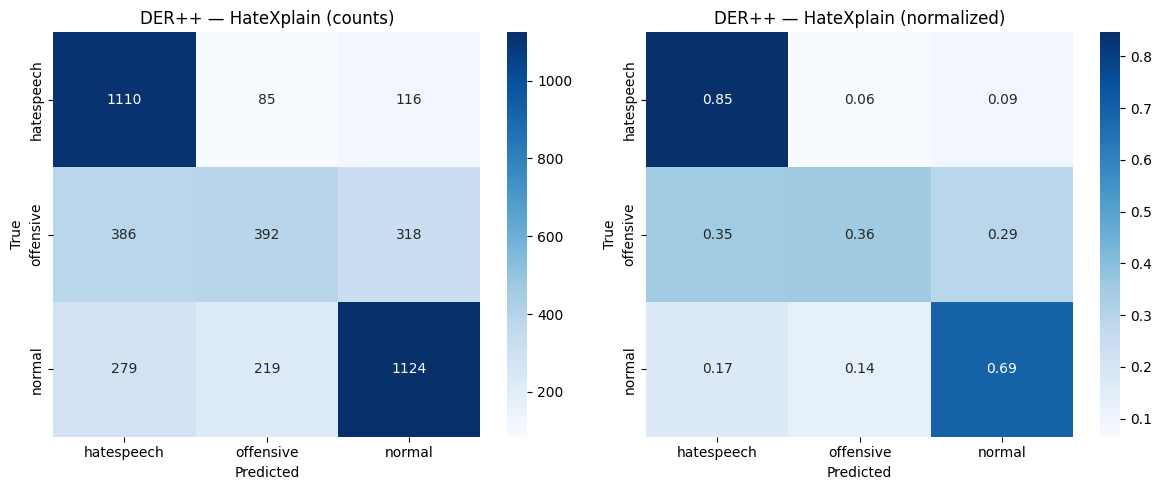

In [11]:
_run_experiment("DER++", EXPERIMENTS["DER++"])

res = cl_results["DER++"]
plot_loss(res["losses"], boundary=res["drift_at"])
plot_eval_log(res["eval_log"], boundary=res["drift_at"])
plot_conf_matrix(res["preds_dv"], res["labels_dv"], LABEL_MAP, title="DER++ — Davidson")
plot_conf_matrix(res["preds_hx"], res["labels_hx"], LABEL_MAP, title="DER++ — HateXplain")

## Final comparison

Aggregates results across all experiments and computes the standard CL metrics.

**BWT** measures how much Davidson performance dropped after HateXplain training,
negative means forgetting, values close to zero mean the strategy successfully
protected the old task knowledge.

**FWT** is the zero-shot accuracy on HateXplain before any of its samples are seen,
measuring how much the Davidson representation transfers to the new domain.

**AAA** captures the full learning dynamics by averaging accuracy across both tasks
at every logged checkpoint, penalizes both slow adaptation and fast forgetting.

**DV Acc / DV F1** are the final accuracy and macro F1 on the Davidson validation set
after the full training stream. F1 macro is more informative than accuracy here given
the class imbalance, a model predicting always offensive would get high accuracy but
low F1.

**HX Acc / HX F1** are the equivalent metrics on HateXplain, measuring how well the
model adapted to the new task after drift detection.

The post-train Davidson evaluation reloads each saved checkpoint and runs inference
on the val set, giving a direct measure of how much each strategy retains Davidson
knowledge after the full training stream. Results are saved to `results.csv`.

c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
c:\Uni\Continual-hate-speech-detection\utils\plot_utils.py:199: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=

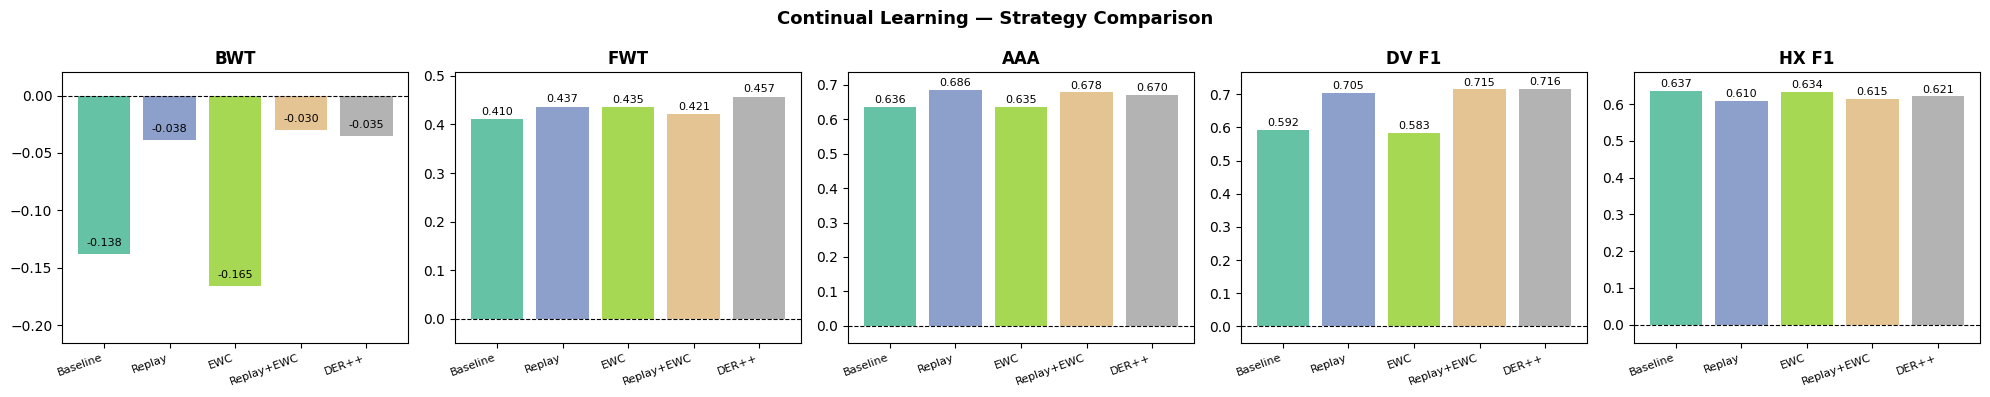

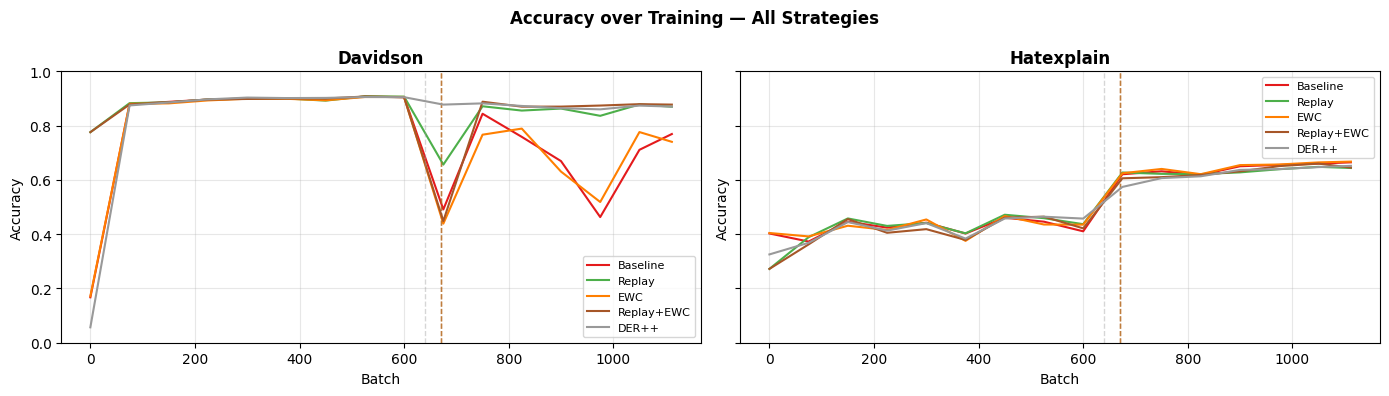

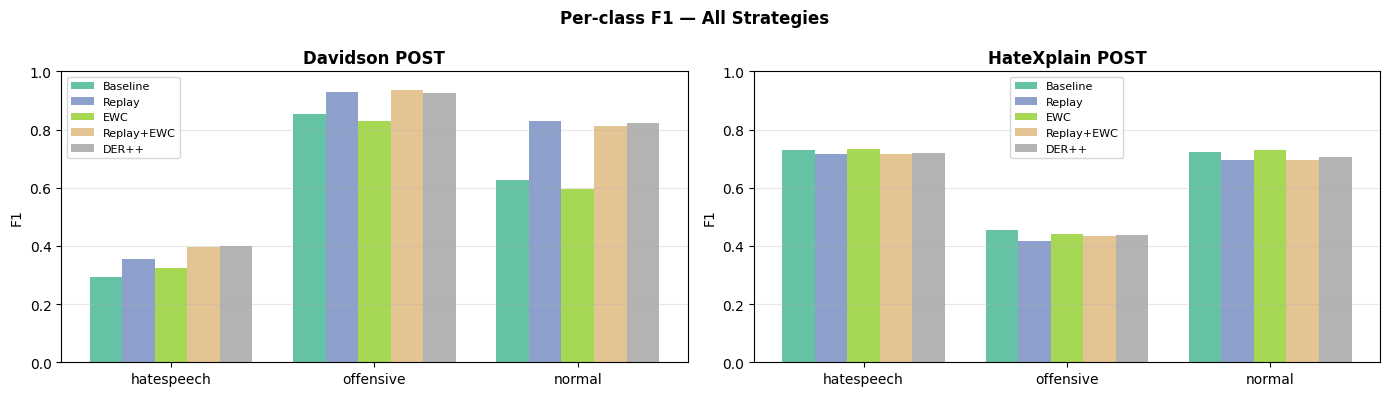

Baseline        Acc=0.7690 | F1=0.5917
Replay          Acc=0.8696 | F1=0.7047
EWC             Acc=0.7402 | F1=0.5829
Replay+EWC      Acc=0.8774 | F1=0.7147
DER++           Acc=0.8700 | F1=0.7159


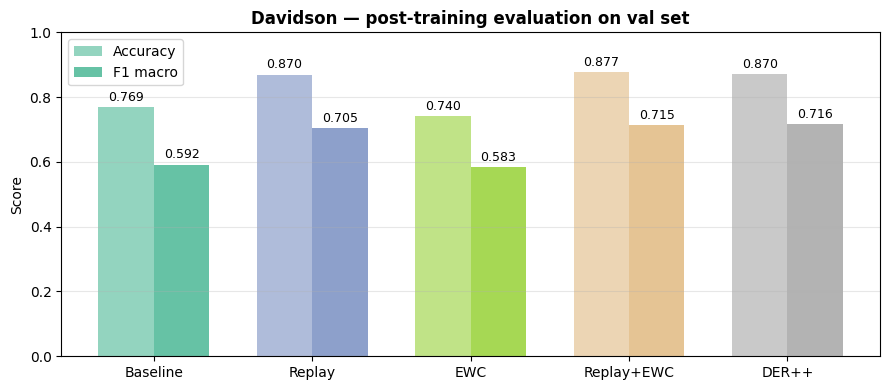

,BWT,Forgetting,FWT,AAA,DV Acc,DV F1,HX Acc,HX F1,Drift batch
Experiment,,,,,,,,,
Baseline,-0.1380,0.1380,0.4105,0.6360,0.7690,0.5917,0.6647,0.6367,671
Replay,-0.0385,0.0385,0.4368,0.6865,0.8696,0.7047,0.6438,0.6097,671
EWC,-0.1654,0.1654,0.4351,0.6352,0.7402,0.5829,0.6674,0.6341,671
Replay+EWC,-0.0298,0.0298,0.4214,0.6785,0.8774,0.7147,0.6453,0.6150,671
DER++,-0.0354,0.0354,0.4574,0.6705,0.8700,0.7159,0.6518,0.6213,639


Saved → results.csv


In [12]:
import pandas as pd
from utils.metrics import compute_accuracy, compute_f1

plot_comparison(cl_results, LABEL_MAP)
plot_eval_logs_comparison(cl_results)
plot_per_class_f1(cl_results, LABEL_MAP)
plot_posttrain_davidson(cl_results, tokenizer, LABEL_MAP, val_stream_dv, DEVICE)

rows = []
for name, res in cl_results.items():
    m = res["metrics"]
    rows.append({
        "Experiment":  name,
        "BWT":         round(m["bwt"], 4),
        "Forgetting":  round(-m["bwt"], 4),
        "FWT":         round(m["fwt"], 4),
        "AAA":         round(m["aaa"], 4),
        "DV Acc":      round(compute_accuracy(res["preds_dv"], res["labels_dv"]), 4),
        "DV F1":       round(compute_f1(res["preds_dv"], res["labels_dv"]), 4),
        "HX Acc":      round(compute_accuracy(res["preds_hx"], res["labels_hx"]), 4),
        "HX F1":       round(compute_f1(res["preds_hx"], res["labels_hx"]), 4),
        "Drift batch": res["drift_at"],
    })

df_results = pd.DataFrame(rows).set_index("Experiment")
display(df_results)
df_results.to_csv("results.csv")
print("Saved → results.csv")

# 📈 Conclusion

All experiments detect the distribution shift at batch 671, confirming ADWIN behaves
consistently across runs regardless of the active strategy.

**Replay-based methods work, EWC alone does not.**
Replay, Replay+EWC and DER++ all reach BWT around -0.03/-0.04, reducing forgetting
by roughly 70-75% compared to the Baseline at -0.14. EWC in isolation scores -0.17,
worse than Baseline on some metrics. The Fisher penalty protects parameters important
for Davidson, but those same parameters are needed to adapt to HateXplain, without
replay bringing Davidson gradients back into training, EWC blocks plasticity without
preventing forgetting.

**All strategies converge to the same HateXplain performance.**
HX F1 is nearly identical across all methods (0.61-0.64), confirming that the
anti-forgetting mechanisms do not interfere with adaptation to the new task. The
stability-plasticity tradeoff is well balanced.

**Offensive remains the hardest class on HateXplain across all strategies (F1 ~0.44).**
This is a dataset-level issue, the boundary between offensive and hatespeech is
inherently ambiguous and both Davidson and HateXplain have known low inter-annotator
agreement on this class. No strategy resolves it, which suggests the ceiling for this
task is lower than the other two classes regardless of the CL method used.

**Post-training evaluation on Davidson val set confirms the BWT findings.**
Replay, Replay+EWC and DER++ maintain strong Davidson performance after the full
training stream (Acc ~0.87, F1 ~0.71), while Baseline and EWC drop to F1 ~0.59.
The gap between the two groups is consistent with the BWT values, validating the
metric as a reliable proxy for real forgetting behaviour.

**DER++ achieves the best FWT (0.457) and AAA (0.670)**, suggesting that logit
distillation provides marginally better forward knowledge transfer compared to
label-only replay. Replay+EWC achieves the best DV F1 (0.715), showing that EWC
contributes a small stability gain when combined with replay even if it adds nothing
when used alone.